<a href="https://colab.research.google.com/github/dhruvsuri8106-code/ECON-3916---Statistical-and-Machine-Learning/blob/main/Lab_23%20/%20lab_23.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages (Colab-safe)
# -----------------------------------------------------------
!pip install datasets nltk scikit-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from datasets import load_dataset

np.random.seed(42)

print('Libraries loaded. Ready to analyze FedSpeak.')

Libraries loaded. Ready to analyze FedSpeak.


In [ ]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 1: Load FOMC minutes dataset
# -----------------------------------------------------------

# Load FOMC dataset from HuggingFace
# This contains FOMC meeting minutes and statements with dates
ds = load_dataset('vtasca/fomc-statements-minutes', split='train')
fomc_df = pd.DataFrame(ds)

# Keep only meeting minutes (filter out shorter policy statements)
fomc_df = fomc_df[fomc_df['Type'] == 'Minute'].copy()
fomc_df.rename(columns={'Text': 'text', 'Date': 'date'}, inplace=True)

# Parse dates and sort chronologically
fomc_df['date'] = pd.to_datetime(fomc_df['date'])
fomc_df = fomc_df.sort_values('date').reset_index(drop=True)

# Add year column for grouping
fomc_df['year'] = fomc_df['date'].dt.year

# Show basic stats
fomc_df['word_count'] = fomc_df['text'].str.split().str.len()

print(f'Total documents: {len(fomc_df)}')
print(f'Date range: {fomc_df["date"].min().date()} to {fomc_df["date"].max().date()}')
print(f'Average word count: {fomc_df["word_count"].mean():.0f}')
print(f'Min / Max word count: {fomc_df["word_count"].min()} / {fomc_df["word_count"].max()}')
print()
print('Sample meeting dates:')
print(fomc_df['date'].head(5).dt.date.tolist())

README.md: 0.00B [00:00, ?B/s]

communications.csv:   0%|          | 0.00/12.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/462 [00:00<?, ? examples/s]

Total documents: 240
Date range: 2000-02-02 to 2026-03-18
Average word count: 7132
Min / Max word count: 3237 / 14364

Sample meeting dates:
[datetime.date(2000, 2, 2), datetime.date(2000, 3, 21), datetime.date(2000, 5, 16), datetime.date(2000, 6, 28), datetime.date(2000, 8, 22)]


In [ ]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 2: Preprocess FOMC minutes text
# -----------------------------------------------------------

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """Clean, tokenize, remove stop words, and lemmatize."""
    # Lowercase
    text = text.lower()
    # Remove non-alphabetic characters (keep spaces)
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stop words and short tokens
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    # Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

# Apply preprocessing to all documents
print('Preprocessing documents... (this may take 30-60 seconds)')
fomc_df['clean_text'] = fomc_df['text'].apply(preprocess_text)

# Show before/after for first document
print('\n=== Before Preprocessing (first 200 chars) ===')
print(fomc_df['text'].iloc[0][:200])
print('\n=== After Preprocessing (first 200 chars) ===')
print(fomc_df['clean_text'].iloc[0][:200])
print(f'\nTokens in first document: {len(fomc_df["clean_text"].iloc[0].split())}')

Preprocessing documents... (this may take 30-60 seconds)

=== Before Preprocessing (first 200 chars) ===
Minutes of the Federal Open Market Committee


February 1-2, 2000





A meeting of the Federal Open Market Committee was held in the offices of the Board of Governors of the Federal Reserve System in

=== After Preprocessing (first 200 chars) ===
minute federal open market committee february meeting federal open market committee held office board governor federal reserve system washington tuesday february continued wednesday february presentmr

Tokens in first document: 4832


In [ ]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 3: Build TF-IDF matrix from preprocessed FOMC text
# -----------------------------------------------------------

# Fill in the blanks:
# - min_df: minimum document frequency (integer, drop very rare words)
# - max_df: maximum document frequency (float, drop ubiquitous words)
# - max_features: cap the vocabulary size (integer)

tfidf = TfidfVectorizer(
    min_df=5,           # Drop words in fewer than 5 documents
    max_df=0.85,           # Drop words in more than 85% of documents
    max_features=10000,     # Keep top 10000 words by TF-IDF score
    ngram_range=(1, 2)    # Include unigrams and bigrams
)

# Fit and transform the preprocessed text
tfidf_matrix = tfidf.fit_transform(fomc_df['clean_text'])

# Get feature names (vocabulary)
feature_names = tfidf.get_feature_names_out()

print(f'TF-IDF matrix shape: {tfidf_matrix.shape}')
print(f'  → {tfidf_matrix.shape[0]} documents × {tfidf_matrix.shape[1]} terms')
print(f'Sparsity: {1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]):.1%}')
print(f'\nSample vocabulary terms: {list(feature_names[:10])}')
print(f'\nTop 10 terms by average TF-IDF across all documents:')
mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
top_indices = mean_tfidf.argsort()[-10:][::-1]
for idx in top_indices:
    print(f'  {feature_names[idx]:25s} {mean_tfidf[idx]:.4f}')

TF-IDF matrix shape: (240, 10000)
  → 240 documents × 10000 terms
Sparsity: 79.6%

Sample vocabulary terms: ['aaronson', 'ab', 'abate', 'abated', 'abating', 'ability', 'ability control', 'able', 'abovetrend', 'abroad']

Top 10 terms by average TF-IDF across all documents:
  messrs                    0.0480
  july                      0.0468
  loan                      0.0461
  january                   0.0457
  october                   0.0436
  september                 0.0425
  august                    0.0411
  march                     0.0401
  june                      0.0397
  april                     0.0385


In [ ]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 4: Compute LM sentiment scores for each FOMC document
# -----------------------------------------------------------

# Simplified Loughran-McDonald word lists (key financial terms)
# In production, load full lists from https://sraf.nd.edu/loughranmcdonald-master-dictionary/
lm_negative = set([
    'adverse', 'adversely', 'against', 'concern', 'concerned', 'concerns',
    'decline', 'declined', 'declining', 'decrease', 'decreased', 'deficit',
    'deteriorate', 'deteriorated', 'deteriorating', 'difficult', 'difficulty',
    'downturn', 'fail', 'failure', 'falling', 'loss', 'losses', 'negative',
    'negatively', 'recession', 'recessionary', 'risk', 'risks', 'risky',
    'severe', 'severely', 'slowdown', 'sluggish', 'stress', 'stressed',
    'threat', 'threaten', 'troubled', 'uncertain', 'uncertainty',
    'unfavorable', 'volatile', 'volatility', 'vulnerability', 'vulnerable',
    'weak', 'weaken', 'weakened', 'weakness', 'worse', 'worsen', 'worsened',
    'worsening', 'worst'
])

lm_positive = set([
    'achieve', 'achieved', 'achievement', 'benefit', 'beneficial', 'confidence',
    'confident', 'favorable', 'gain', 'gained', 'gains', 'good', 'growth',
    'improve', 'improved', 'improvement', 'improving', 'increase', 'increased',
    'opportunity', 'opportunities', 'optimism', 'optimistic', 'positive',
    'positively', 'profit', 'profitable', 'progress', 'prosper', 'prosperity',
    'rebound', 'recover', 'recovered', 'recovery', 'strength', 'strengthen',
    'strengthened', 'strong', 'stronger', 'strongest', 'success', 'successful',
    'upturn', 'upward'
])

lm_uncertainty = set([
    'approximate', 'approximately', 'assume', 'assumption', 'believe',
    'cautious', 'could', 'depend', 'depends', 'doubt', 'doubtful',
    'estimate', 'estimated', 'expect', 'expected', 'forecast', 'foreseeable',
    'indefinite', 'indefinitely', 'likelihood', 'may', 'might', 'nearly',
    'pending', 'perhaps', 'possible', 'possibly', 'predict', 'prediction',
    'preliminary', 'probable', 'probably', 'project', 'projected',
    'risk', 'roughly', 'seem', 'seemed', 'seemingly', 'suggest',
    'tentative', 'uncertain', 'uncertainty', 'unclear', 'unpredictable',
    'variable'
])


def compute_lm_sentiment(text, neg_words, pos_words, unc_words):
    """
    Compute Loughran-McDonald sentiment scores.

    Returns dict with 'net_sentiment', 'uncertainty', 'neg_count', 'pos_count'
    """
    tokens = text.lower().split()
    total = len(tokens)

    if total == 0:
        return {'net_sentiment': 0, 'uncertainty': 0, 'neg_count': 0, 'pos_count': 0}

    # Fill in: Count how many tokens are in each word list
    neg_count = sum(1 for t in tokens if t in neg_words)
    pos_count = sum(1 for t in tokens if t in pos_words)
    unc_count = sum(1 for t in tokens if t in unc_words)

    # Fill in: Compute net sentiment = (pos - neg) / total
    net_sentiment = (pos_count  - neg_count) / total
    uncertainty = unc_count / total

    return {
        'net_sentiment': net_sentiment,
        'uncertainty': uncertainty,
        'neg_count': neg_count,
        'pos_count': pos_count,
        'unc_count': unc_count,
        'total_words': total
    }


# Apply to all documents
sentiment_results = fomc_df['clean_text'].apply(
    lambda x: compute_lm_sentiment(x, lm_negative, lm_positive, lm_uncertainty)
)

# Convert to DataFrame columns
sentiment_df = pd.DataFrame(sentiment_results.tolist())
fomc_df = pd.concat([fomc_df, sentiment_df], axis=1)

print('=== Sentiment Summary ===')
print(f'Mean net sentiment: {fomc_df["net_sentiment"].mean():.6f}')
print(f'Std net sentiment:  {fomc_df["net_sentiment"].std():.6f}')
print(f'Mean uncertainty:   {fomc_df["uncertainty"].mean():.6f}')
print()
print('Most negative meeting:', fomc_df.loc[fomc_df['net_sentiment'].idxmin(), 'date'].date())
print('Most positive meeting:', fomc_df.loc[fomc_df['net_sentiment'].idxmax(), 'date'].date())

=== Sentiment Summary ===
Mean net sentiment: 0.007009
Std net sentiment:  0.008706
Mean uncertainty:   0.021756

Most negative meeting: 2008-12-16
Most positive meeting: 2004-06-30


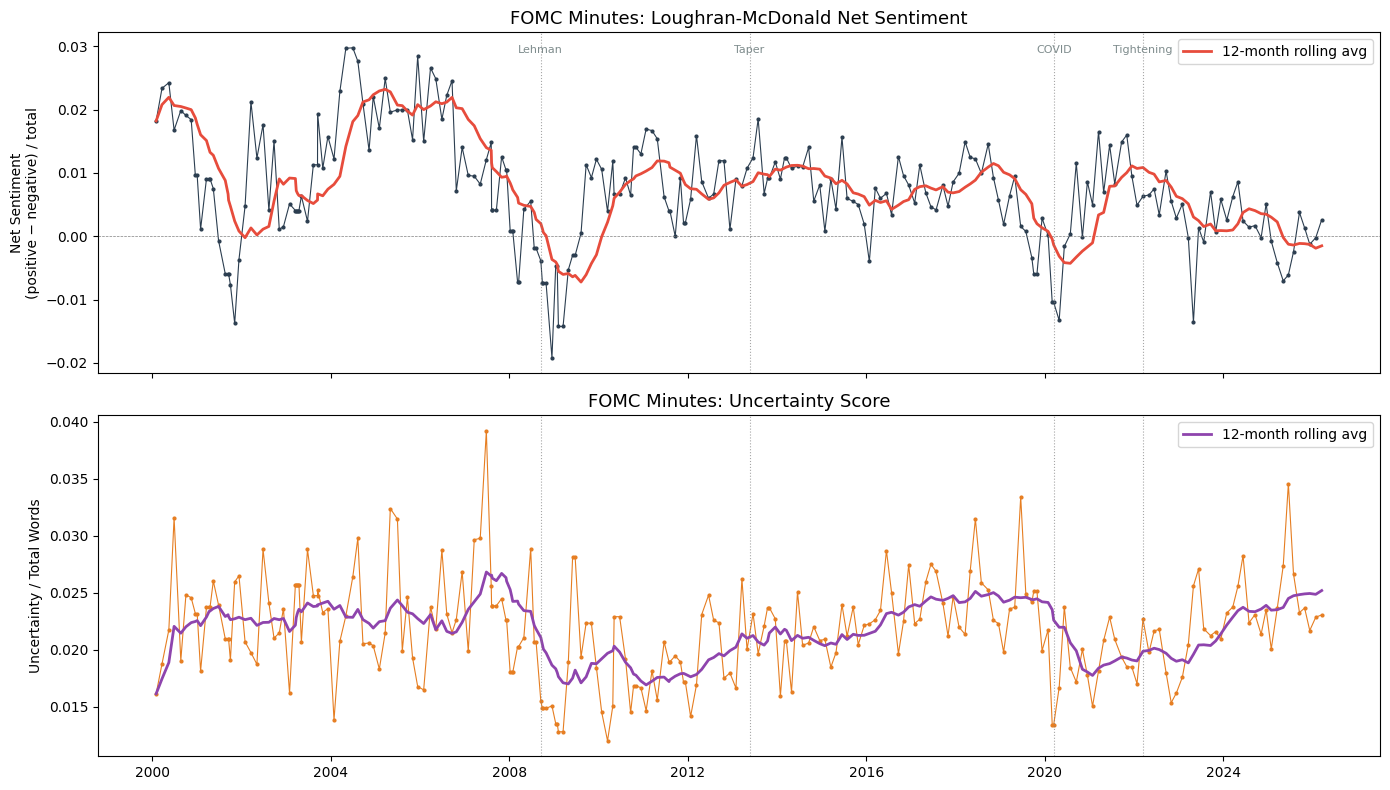

In [ ]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 5: Plot sentiment time series with event annotations
# -----------------------------------------------------------

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Panel 1: Net Sentiment
axes[0].plot(fomc_df['date'], fomc_df['net_sentiment'], color='#2c3e50',
             linewidth=0.8, marker='o', markersize=2)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.5)

# Rolling average
rolling_sent = fomc_df.set_index('date')['net_sentiment'].rolling('365D').mean()
axes[0].plot(rolling_sent.index, rolling_sent.values, color='#e74c3c',
             linewidth=2.0, label='12-month rolling avg')

axes[0].set_title('FOMC Minutes: Loughran-McDonald Net Sentiment', fontsize=13)
axes[0].set_ylabel('Net Sentiment\n(positive − negative) / total')
axes[0].legend()

# Panel 2: Uncertainty
axes[1].plot(fomc_df['date'], fomc_df['uncertainty'], color='#e67e22',
             linewidth=0.8, marker='o', markersize=2)
rolling_unc = fomc_df.set_index('date')['uncertainty'].rolling('365D').mean()
axes[1].plot(rolling_unc.index, rolling_unc.values, color='#8e44ad',
             linewidth=2.0, label='12-month rolling avg')

axes[1].set_title('FOMC Minutes: Uncertainty Score', fontsize=13)
axes[1].set_ylabel('Uncertainty / Total Words')
axes[1].legend()

# Annotate key events
events = [
    ('2008-09-15', 'Lehman'),
    ('2013-05-22', 'Taper'),
    ('2020-03-15', 'COVID'),
    ('2022-03-16', 'Tightening'),
]
for date_str, label in events:
    date = pd.Timestamp(date_str)
    for ax in axes:
        ax.axvline(date, color='gray', linestyle=':', linewidth=0.8, alpha=0.7)
    axes[0].annotate(label, xy=(date, axes[0].get_ylim()[1] * 0.9),
                     fontsize=8, color='#7f8c8d', ha='center')

plt.tight_layout()
plt.show()

Explained variance (50 components): 70.2%
Silhouette score (K=3): 0.156
  (Note: text data typically has lower silhouette than numerical data)


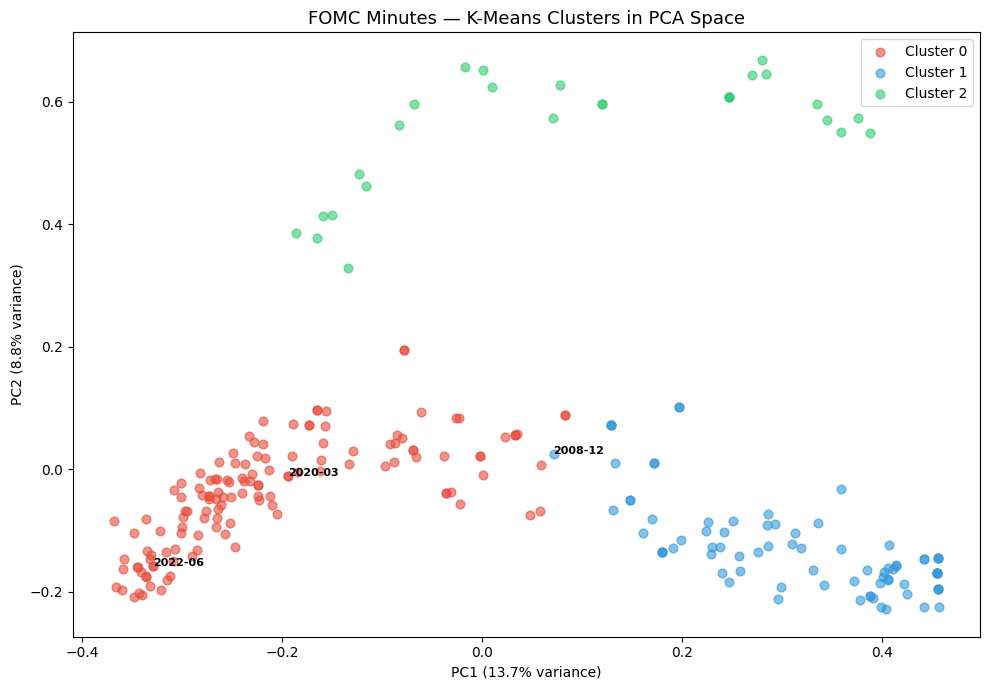


=== Cluster Composition ===
Cluster 0: 133 documents, 2009-02-07 to 2026-03-18
Cluster 1: 80 documents, 2000-03-21 to 2008-12-16
Cluster 2: 27 documents, 2000-02-02 to 2022-01-26


In [ ]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 6: Cluster FOMC documents with K-Means on TF-IDF
# -----------------------------------------------------------

# Step A: Reduce TF-IDF to 50 dimensions with PCA (TruncatedSVD for sparse)
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=50, random_state=42)
tfidf_reduced = svd.fit_transform(tfidf_matrix)

print(f'Explained variance (50 components): {svd.explained_variance_ratio_.sum():.1%}')

# Step B: K-Means with K=3 (pre-GFC, GFC-era, post-COVID)
# Fill in the blanks:
# - n_clusters: how many clusters?
# - random_state: for reproducibility
# - n_init: number of initializations

kmeans = KMeans(
    n_clusters=3,      # How many language regimes?
    random_state=42,
    n_init=10           # Number of random initializations (10 is standard)
)

fomc_df['cluster'] = kmeans.fit_predict(tfidf_reduced)

# Step C: Evaluate with silhouette score
sil_score = silhouette_score(tfidf_reduced, fomc_df['cluster'])
print(f'Silhouette score (K=3): {sil_score:.3f}')
print('  (Note: text data typically has lower silhouette than numerical data)')

# Step D: Visualize clusters in 2D PCA space
pca_2d = PCA(n_components=2, random_state=42)
coords_2d = pca_2d.fit_transform(tfidf_reduced)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c', '#3498db', '#2ecc71']
for k in range(3):
    mask = fomc_df['cluster'] == k
    ax.scatter(coords_2d[mask, 0], coords_2d[mask, 1],
               c=colors[k], alpha=0.6, s=40, label=f'Cluster {k}')

# Label a few key dates
key_dates = ['2008-12-16', '2020-03-15', '2022-06-15']
for d in key_dates:
    idx_match = fomc_df.index[fomc_df['date'].dt.strftime('%Y-%m-%d') == d]
    if len(idx_match) > 0:
        idx = idx_match[0]
        ax.annotate(d[:7], xy=(coords_2d[idx, 0], coords_2d[idx, 1]),
                    fontsize=8, fontweight='bold')

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('FOMC Minutes — K-Means Clusters in PCA Space', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

# Show cluster date ranges
print('\n=== Cluster Composition ===')
for k in range(3):
    cluster_docs = fomc_df[fomc_df['cluster'] == k]
    print(f'Cluster {k}: {len(cluster_docs)} documents, '
          f'{cluster_docs["date"].min().date()} to {cluster_docs["date"].max().date()}')

=== Pre-COVID (before March 2020) ===
  Documents: 190
  Mean net sentiment: 0.008107
  Mean uncertainty:   0.021894

=== Post-COVID (March 2020 onward) ===
  Documents: 50
  Mean net sentiment: 0.002840
  Mean uncertainty:   0.021233


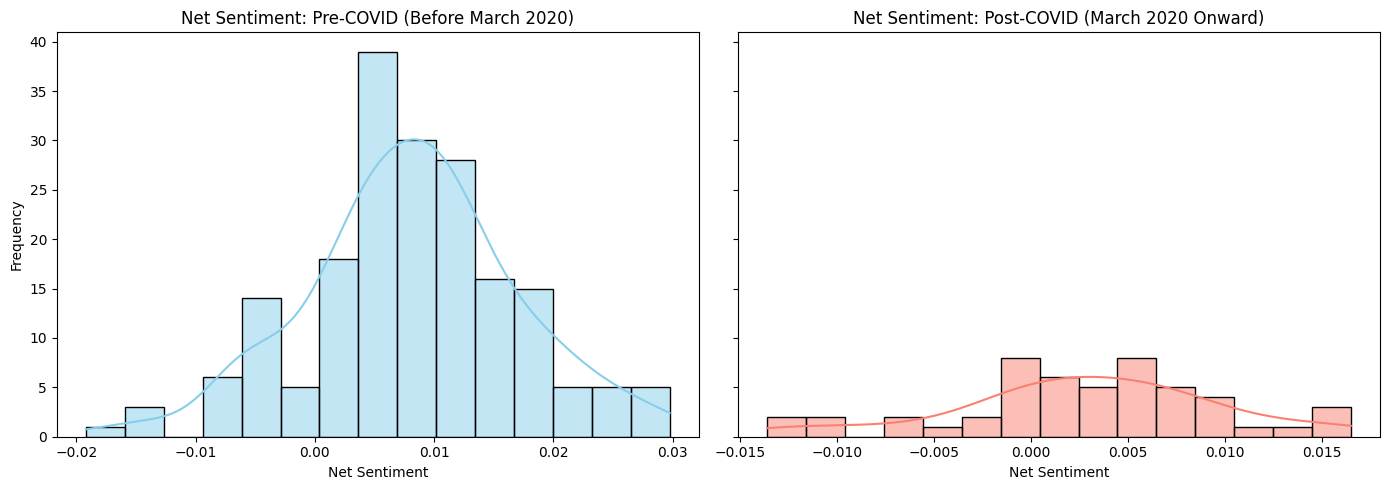

In [ ]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Challenge: Compare sentiment regimes
# -----------------------------------------------------------

import seaborn as sns # Import seaborn for plotting

# Split into pre-2020 and post-2020
pre_covid = fomc_df[fomc_df['date'] < '2020-03-01']
post_covid = fomc_df[fomc_df['date'] >= '2020-03-01']

print('=== Pre-COVID (before March 2020) ===')
print(f'  Documents: {len(pre_covid)}')
print(f'  Mean net sentiment: {pre_covid["net_sentiment"].mean():.6f}')
print(f'  Mean uncertainty:   {pre_covid["uncertainty"].mean():.6f}')

print('\n=== Post-COVID (March 2020 onward) ===')
print(f'  Documents: {len(post_covid)}')
print(f'  Mean net sentiment: {post_covid["net_sentiment"].mean():.6f}')
print(f'  Mean uncertainty:   {post_covid["uncertainty"].mean():.6f}')

# YOUR TASK: Create a visualization comparing the two periods
# Options:
#   - Side-by-side histograms of net sentiment

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

sns.histplot(pre_covid['net_sentiment'], kde=True, ax=axes[0], color='skyblue', bins=15)
axes[0].set_title('Net Sentiment: Pre-COVID (Before March 2020)')
axes[0].set_xlabel('Net Sentiment')
axes[0].set_ylabel('Frequency')

sns.histplot(post_covid['net_sentiment'], kde=True, ax=axes[1], color='salmon', bins=15)
axes[1].set_title('Net Sentiment: Post-COVID (March 2020 Onward)')
axes[1].set_xlabel('Net Sentiment')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Following the pandemic, it appears that the federal reserve became significantly more negative, with a much lower net sentiment. The uncertainty before and after COVID appears to be relatively similar, although it is slightly higher post COVID. The reason for the Fed's negativity can likely be explained due to the recession in 2020, which caused numerous job losses and decreases in income, so purchasing power was limited and the economy was worse, explaining the Fed's negativity.